# Data preparation

The **neuralgcm-torch** version of the upstream
[data_preparation](https://github.com/neuralgcm/neuralgcm/blob/main/docs/data_preparation.ipynb)
notebook: preparing ERA5-style data for NeuralGCM and converting between
`xarray.Dataset` and the dict-of-tensors format used by the model API.
Needs network access for the ERA5 data (anonymous GCS).

NeuralGCM models take and produce data on ERA5's
[37 pressure levels](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels),
including the following variables, provided in SI units on the NeuralGCM
model's native grid:

- Inputs/outputs (on pressure levels): `u_component_of_wind`,
  `v_component_of_wind`, `geopotential`, `temperature`,
  `specific_humidity`, `specific_cloud_ice_water_content`,
  `specific_cloud_liquid_water_content`.
- Forcings (surface level only): `sea_surface_temperature`,
  `sea_ice_cover`.

`sim_time` is the only exception, which gives time in NeuralGCM's internal
nondimensional units.

## Regridding data

Preparing a dataset stored on a different horizontal grid for NeuralGCM
requires two steps:

1. Horizontal regridding to a Gaussian grid. For processing
   fine-resolution data conservative regridding is most appropriate (and
   is what we used to train NeuralGCM).
2. Filling in all missing values (NaN), to ensure all inputs are valid.
   Forcing fields like `sea_surface_temperature` are only defined over
   ocean in ERA5, and NeuralGCM's surface model also includes a mask that
   ignores values over land.

In [2]:
import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation
from dinosaur_torch import xarray_utils
import neuralgcm_torch as neuralgcm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
from neuralgcm_torch import pretrained
# Fetched from the Hugging Face Hub on first use (cached), or reused from
# a local checkpoints/ directory if present.
converted_path = pretrained.fetch_checkpoint('tl63_stochastic_mini', local_root='checkpoints')
model = neuralgcm.PressureLevelModel.from_checkpoint(converted_path, device=device)

In [4]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)
full_era5

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * time                                                             (time) datetime64[ns] 11MB ...
  * latitude                                                         (latitude) float32 3kB ...
  * longitude                                                        (longitude) float32 6kB ...
  * level                                                            (level) int64 296B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2026-06-12 02:43:37.240316+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-06-06

Based on this dataset and our model grid, we can build a `Regridder` object:

In [5]:
full_era5_grid = xarray_utils.grid_spec_from_dataset(full_era5)
regridder = horizontal_interpolation.ConservativeRegridder(
    full_era5_grid, model.data_grid, skipna=True, device=device
)

`skipna=True` in `ConservativeRegridder` means grid cells with a mix of
NaN/non-NaN values should be filled skipping NaN values. This ensures sea
surface temperature and sea ice cover remains defined in coarse grid cells
that overlap coastlines.

Regridding requires the data to be first loaded into memory. Because this
full dataset is gigantic (100s of TB) we'll only regrid a single time
point:

In [6]:
variables = model.input_variables + model.forcing_variables
sliced_era5 = full_era5[variables].sel(time='2020-01-01T00').compute()
sliced_era5

<xarray.Dataset> Size: 1GB
Dimensions:                              (level: 37, latitude: 721,
                                          longitude: 1440)
Coordinates:
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * latitude                             (latitude) float32 3kB 90.0 ... -90.0
  * longitude                            (longitude) float32 6kB 0.0 ... 359.8
    time                                 datetime64[ns] 8B 2020-01-01
Data variables:
    geopotential                         (level, latitude, longitude) float32 154MB ...
    specific_humidity                    (level, latitude, longitude) float32 154MB ...
    temperature                          (level, latitude, longitude) float32 154MB ...
    u_component_of_wind                  (level, latitude, longitude) float32 154MB ...
    v_component_of_wind                  (level, latitude, longitude) float32 154MB ...
    specific_cloud_ice_water_content     (level, latitude, longitude) float32 154MB ...
    specific_cloud_liquid_water_content  (level, latitude, longitude) float32 154MB ...
    sea_ice_cover                        (latitude, longitude) float32 4MB 1....
    sea_surface_temperature              (latitude, longitude) float32 4MB 27...
Attributes:
    last_updated:           2026-06-12 02:43:37.240316+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-06-06

In [7]:
regridded = xarray_utils.regrid_horizontal(sliced_era5, regridder)
regridded

<xarray.Dataset> Size: 9MB
Dimensions:                              (level: 37, longitude: 128,
                                          latitude: 64)
Coordinates:
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
    time                                 datetime64[ns] 8B 2020-01-01
Data variables:
    geopotential                         (level, longitude, latitude) float32 1MB ...
    specific_humidity                    (level, longitude, latitude) float32 1MB ...
    temperature                          (level, longitude, latitude) float32 1MB ...
    u_component_of_wind                  (level, longitude, latitude) float32 1MB ...
    v_component_of_wind                  (level, longitude, latitude) float32 1MB ...
    specific_cloud_ice_water_content     (level, longitude, latitude) float32 1MB ...
    specific_cloud_liquid_water_content  (level, longitude, latitude) float32 1MB ...
    sea_ice_cover                        (longitude, latitude) float32 33kB n...
    sea_surface_temperature              (longitude, latitude) float32 33kB n...
Attributes:
    last_updated:           2026-06-12 02:43:37.240316+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-06-06

Looking at the data, we see that sea surface temperature is now on a much coarser grid (roughly 2.8°).

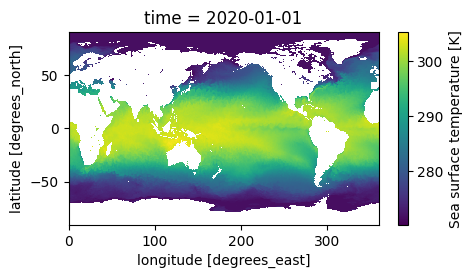

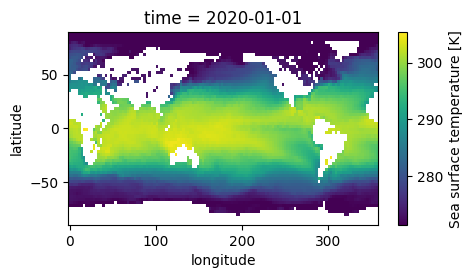

In [8]:
sliced_era5.sea_surface_temperature.plot(x='longitude', y='latitude', aspect=2, size=2.5);
regridded.sea_surface_temperature.plot(x='longitude', y='latitude', aspect=2, size=2.5);

However, we still have missing values (NaN) in the locations shown in
white over land. We'll fill those with values from the nearest non-missing
locations:

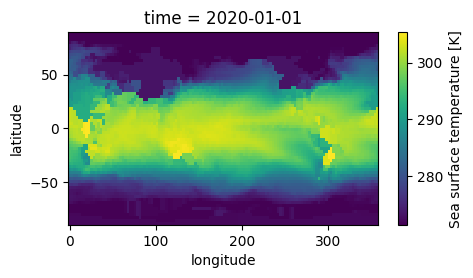

In [9]:
regridded_and_filled = xarray_utils.fill_nan_with_nearest(regridded)
regridded_and_filled.sea_surface_temperature.plot(x='longitude', y='latitude', aspect=2, size=2.5);

Now we have a dataset ready for feeding into NeuralGCM!

## Converting to/from Xarray

NeuralGCM's learned methods transform data in the form of dictionaries of
torch tensors:

- Expected dict keys for `inputs` and `forcings` are indicated by
  `model.input_variables` and `model.forcing_variables`.
- Dictionary values are tensors with shape
  `(time, level, longitude, latitude)` for pressure-level variables and
  `(time, longitude, latitude)` for surface forcings. A leading time axis
  is always present (length one for a single snapshot).

`inputs_from_xarray` and `forcings_from_xarray` convert `xarray.Dataset`
objects with the appropriate variables into dictionary-of-tensors format
(an optional `device=` argument overrides the model's device, e.g. for
data loading on CPU):

In [10]:
inputs = model.inputs_from_xarray(regridded_and_filled)
forcings = model.forcings_from_xarray(regridded_and_filled)

In [11]:
{k: tuple(v.shape) for k, v in inputs.items()}

{'geopotential': (1, 37, 128, 64),
 'specific_humidity': (1, 37, 128, 64),
 'temperature': (1, 37, 128, 64),
 'u_component_of_wind': (1, 37, 128, 64),
 'v_component_of_wind': (1, 37, 128, 64),
 'specific_cloud_ice_water_content': (1, 37, 128, 64),
 'specific_cloud_liquid_water_content': (1, 37, 128, 64),
 'sim_time': (1,)}

In [12]:
{k: tuple(v.shape) for k, v in forcings.items()}

{'sea_ice_cover': (1, 128, 64),
 'sea_surface_temperature': (1, 128, 64),
 'sim_time': (1,)}

Notice that `sim_time` was calculated automatically. It can also be
calculated explicitly from `numpy.datetime64` arrays using
`datetime64_to_sim_time`:

In [13]:
inputs['sim_time']

tensor([188693.6250], device='cuda:0')

In [14]:
model.datetime64_to_sim_time(np.atleast_1d(regridded_and_filled.time.data))

array([188693.6256])

Outputs from NeuralGCM can be converted back into an `xarray.Dataset` with
appropriate coordinates via `data_to_xarray`. Pass `times=None` if the
arrays have no leading time-axis (e.g. the outputs of `decode`), or supply
a 1D array of time values matching the leading axis:

In [15]:
model.data_to_xarray(
    model.inputs_from_xarray(regridded_and_filled),
    times=np.atleast_1d(regridded_and_filled.time.data),
)

<xarray.Dataset> Size: 8MB
Dimensions:                              (time: 1, level: 37, longitude: 128,
                                          latitude: 64)
Coordinates:
  * time                                 (time) datetime64[ns] 8B 2020-01-01
  * level                                (level) float64 296B 1.0 2.0 ... 1e+03
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    geopotential                         (time, level, longitude, latitude) float32 1MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 1MB ...
    temperature                          (time, level, longitude, latitude) float32 1MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 1MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 1MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 1MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 1MB ...

In principle, `sim_time_to_datetime64` can calculate output times
automatically (e.g., from the outputs of `unroll`), but this isn't
recommended. Like JAX, this port does math in float32 mode, which can
result in significant rounding errors (e.g., up to a few minutes). As
illustrated in the forecast_quickstart notebook, we recommend calculating
times directly with NumPy or pandas.

## Time shifting

In the NeuralGCM paper, we used one other data preparation trick for
forcing variables: we shifted them backwards in time (by one day), so we
could not be accused of leaking data from the future into our weather
forecasts.

This can be reproduced with the `selective_temporal_shift()` utility,
which acts lazily even on datasets that do not fit into memory:

In [16]:
xarray_utils.selective_temporal_shift(
    dataset=full_era5,
    variables=model.forcing_variables,
    time_shift='24 hours',
)

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323624,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * time                                                             (time) datetime64[ns] 11MB ...
  * latitude                                                         (latitude) float32 3kB ...
  * longitude                                                        (longitude) float32 6kB ...
  * level                                                            (level) int64 296B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2026-06-12 02:43:37.240316+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-06-06